
# Churn Prediction — **Tableau‑Ready** End‑to‑End Notebook

This notebook upgrades a basic churn model into a production‑style pipeline with:
- Clean preprocessing & feature engineering
- Multiple models with validation and **best‑model selection**
- **Explainability** (SHAP) and feature importance
- Exported artifacts for Tableau: `predictions.csv`, `metrics.csv`, `feature_importance.csv`, `shap_summary.png`, `model.pkl`
- (Optional) **TabPy integration** for live inference from Tableau

> **How to use:** Run cells top‑to‑bottom. At the end you'll get CSVs and images ready to connect in Tableau Desktop/Public.


In [1]:

# If running locally and you don't have these, uncomment the next line to install.
# You may need to restart the kernel after installation.
# !pip install -U pandas numpy scikit-learn shap xgboost joblib matplotlib tabpy-client
# %pip install shap


## 1. Initializing the project

In [2]:

import os
import sys
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from typing import List, Tuple

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    roc_auc_score, accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, RocCurveDisplay
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Optional: XGBoost (will be used if available)
try:
    from xgboost import XGBClassifier
    XGB_AVAILABLE = True
except Exception:
    XGB_AVAILABLE = False

# SHAP for explainability (TreeExplainer/LinearExplainer)
import shap
shap.__version__  # Ensure it imports cleanly

# Paths
DATA_PATH = "data.csv"  # Change if your CSV has a different path
ARTIFACT_DIR = "artifacts"
os.makedirs(ARTIFACT_DIR, exist_ok=True)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print(f"XGBoost available: {XGB_AVAILABLE}")
print(f"Artifacts will be saved to: {os.path.abspath(ARTIFACT_DIR)}")


XGBoost available: False
Artifacts will be saved to: e:\PYTHON\AI-ML-DS\Projects\churn prediction model\artifacts


## 2. Data Collection

Data shape: (10000, 14)


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


Guessed target column: Exited
Detected ID column: CustomerId
Exited
0    7963
1    2037
Name: count, dtype: int64


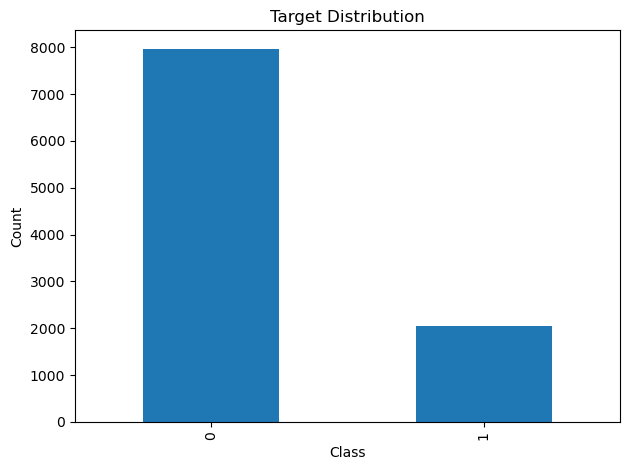

In [3]:

# ---- Load dataset ----
assert os.path.exists(DATA_PATH), f"Data file not found at {DATA_PATH}. Please update DATA_PATH."
df = pd.read_csv(DATA_PATH)
print("Data shape:", df.shape)
display(df.head())

# ---- Guess target column ----
def guess_target_column(columns: List[str], df: pd.DataFrame) -> str:
    # Common churn/target names
    candidates = ["churn", "Churn", "CHURN", "Exited", "Target", "target", "Label", "label", "y"]
    for c in candidates:
        if c in columns:
            return c
    # Otherwise pick a binary column (0/1 or Yes/No) with reasonable balance
    for col in columns[::-1]:  # start from end (often target is last)
        unique_vals = df[col].dropna().unique()
        if len(unique_vals) == 2:
            return col
    # Fallback: last column
    return columns[-1]

# ---- Guess ID column (optional) ----
def guess_id_column(columns: List[str]) -> str:
    id_candidates = ["customerid", "CustomerID", "customerID", "customer_id", "Customer_ID",
                     "customer", "Customer", "ID", "Id", "id"]
    lower_cols = [c.lower() for c in columns]
    for c in id_candidates:
        if c.lower() in lower_cols:
            idx = lower_cols.index(c.lower())
            return columns[idx]
    return None

target_col = guess_target_column(df.columns.tolist(), df)
id_col = guess_id_column(df.columns.tolist())
print("Guessed target column:", target_col)
print("Detected ID column:", id_col)

# Ensure target is binary (coerce if 'Yes'/'No' etc.)
if df[target_col].dtype == 'O':
    # Try map common labels
    mapping = {"Yes": 1, "No": 0, "Y": 1, "N": 0, "True": 1, "False": 0, "Male": 1, "Female": 0}
    df[target_col] = df[target_col].map(lambda x: mapping.get(str(x), x))
# If still not numeric, try factorize (will be 0/1 if 2 unique values)
if not np.issubdtype(df[target_col].dtype, np.number):
    df[target_col], _ = pd.factorize(df[target_col])

# Drop rows with missing target
df = df[~df[target_col].isna()].copy()
df[target_col] = df[target_col].astype(int)
print(df[target_col].value_counts(dropna=False))

# Quick target distribution plot (matplotlib only)
fig = plt.figure()
df[target_col].value_counts().sort_index().plot(kind="bar")
plt.title("Target Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


## 3. Data Preprocessing 

In [4]:

# Separate features/target
X = df.drop(columns=[target_col])
y = df[target_col].astype(int)

# Identify numerical and categorical columns
numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = X.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

print("Numeric cols:", numeric_cols[:10], "..." if len(numeric_cols) > 10 else "")
print("Categorical cols:", categorical_cols[:10], "..." if len(categorical_cols) > 10 else "")

# Imputers & encoders
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_cols),
        ("cat", categorical_transformer, categorical_cols)
    ]
)

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y if y.nunique()==2 else None
)
print("Train/Test sizes:", X_train.shape, X_test.shape)


Numeric cols: ['RowNumber', 'CustomerId', 'CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary'] 
Categorical cols: ['Surname', 'Geography', 'Gender'] 
Train/Test sizes: (8000, 13) (2000, 13)


## 4. Model Training & Selection

In [5]:

models = []
models.append(("LogReg", LogisticRegression(max_iter=500, class_weight="balanced")))
models.append(("RF", RandomForestClassifier(n_estimators=400, max_depth=None, n_jobs=-1, random_state=RANDOM_STATE, class_weight="balanced")))
if XGB_AVAILABLE:
    models.append(("XGB", XGBClassifier(
        n_estimators=600, max_depth=6, learning_rate=0.05, subsample=0.9, colsample_bytree=0.9,
        reg_lambda=1.0, random_state=RANDOM_STATE, tree_method="hist", eval_metric="logloss"
    )))

results = []
best_auc = -1.0
best_name = None
best_pipe = None

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE) if y.nunique()==2 else None

for name, clf in models:
    pipe = Pipeline(steps=[("prep", preprocessor), ("clf", clf)])
    if y.nunique()==2 and cv is not None:
        auc = cross_val_score(pipe, X, y, cv=cv, scoring="roc_auc").mean()
    else:
        auc = cross_val_score(pipe, X, y, cv=5, scoring="accuracy").mean()
    results.append((name, auc))
    print(f"{name} CV score: {auc:.4f}")
    if auc > best_auc:
        best_auc = auc
        best_name = name
        best_pipe = pipe

print("\nBest model:", best_name, "with score:", round(best_auc, 4))

# Fit best model on train
best_pipe.fit(X_train, y_train)

# Save the fitted pipeline
joblib.dump(best_pipe, os.path.join(ARTIFACT_DIR, "model.pkl"))
print("Saved model to artifacts/model.pkl")


LogReg CV score: 0.7421
RF CV score: 0.8478

Best model: RF with score: 0.8478
Saved model to artifacts/model.pkl


## 5. Model Prediction & Evaluation

Test metrics: {
  "roc_auc": 0.8517099534048687,
  "accuracy": 0.85,
  "precision": 0.8407643312101911,
  "recall": 0.32432432432432434,
  "f1": 0.46808510638297873
}
Confusion Matrix:
 [[1568   25]
 [ 275  132]]
Saved metrics to artifacts/metrics.csv


<Figure size 640x480 with 0 Axes>

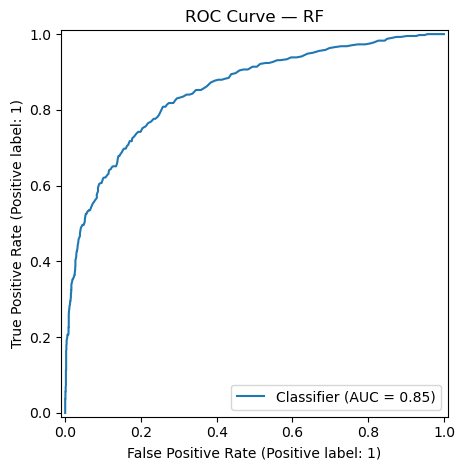

Saved ROC figure to artifacts\roc_curve.png


In [6]:

# Predict
y_proba = None
try:
    y_proba = best_pipe.predict_proba(X_test)[:, 1]
except Exception:
    # Some models may not have predict_proba; fallback to decision_function if available
    if hasattr(best_pipe.named_steps["clf"], "decision_function"):
        scores = best_pipe.decision_function(X_test)
        # Normalize to 0-1
        y_proba = (scores - scores.min()) / (scores.max() - scores.min() + 1e-8)
    else:
        y_proba = best_pipe.predict(X_test)

y_pred = (y_proba >= 0.5).astype(int) if y_proba is not None else best_pipe.predict(X_test)

# Metrics
metrics = {}
if y.nunique() == 2:
    metrics["roc_auc"] = float(roc_auc_score(y_test, y_proba))
metrics.update({
    "accuracy": float(accuracy_score(y_test, y_pred)),
    "precision": float(precision_score(y_test, y_pred, zero_division=0)),
    "recall": float(recall_score(y_test, y_pred, zero_division=0)),
    "f1": float(f1_score(y_test, y_pred, zero_division=0)),
})

print("Test metrics:", json.dumps(metrics, indent=2))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

# Export metrics
metrics_df = pd.DataFrame([{"model": best_name, **metrics}])
metrics_df.to_csv(os.path.join(ARTIFACT_DIR, "metrics.csv"), index=False)
print("Saved metrics to artifacts/metrics.csv")

# ROC curve (if binary)
if y.nunique() == 2:
    fig = plt.figure()
    RocCurveDisplay.from_predictions(y_test, y_proba)
    plt.title(f"ROC Curve — {best_name}")
    plt.tight_layout()
    fig_path = os.path.join(ARTIFACT_DIR, "roc_curve.png")
    plt.savefig(fig_path, dpi=160)
    plt.show()
    print("Saved ROC figure to", fig_path)


## 6. Feature Importance

Saved feature importance to artifacts/feature_importance.csv


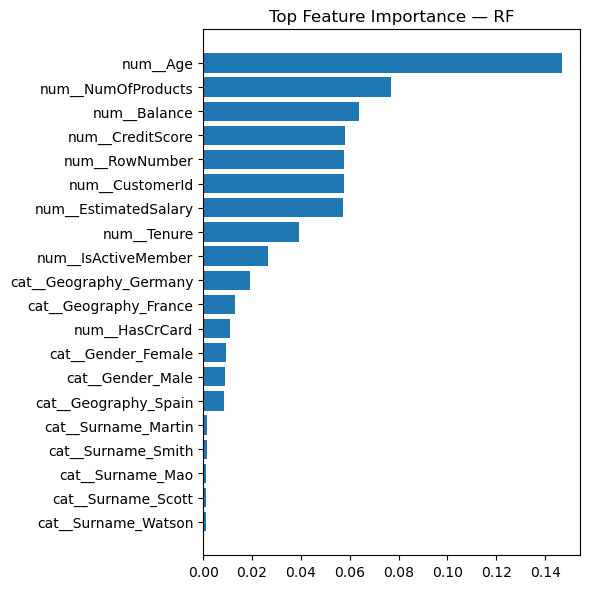

Saved feature importance figure to artifacts\feature_importance_top20.png


In [7]:

# Derive feature names after preprocessing
prep = best_pipe.named_steps["prep"]
final_clf = best_pipe.named_steps["clf"]

feature_names = []
if hasattr(prep, "get_feature_names_out"):
    feature_names = prep.get_feature_names_out()
else:
    # Fallback names
    feature_names = (
        [f"num__{c}" for c in numeric_cols] +
        [f"cat__{c}" for c in categorical_cols]
    )

# Feature importance / coefficients
fi_df = None
if hasattr(final_clf, "feature_importances_"):
    fi = final_clf.feature_importances_
    fi_df = pd.DataFrame({"feature": feature_names, "importance": fi}).sort_values("importance", ascending=False)
elif hasattr(final_clf, "coef_"):
    coefs = np.ravel(final_clf.coef_)
    fi_df = pd.DataFrame({"feature": feature_names, "importance": np.abs(coefs)}).sort_values("importance", ascending=False)

if fi_df is not None:
    fi_df.to_csv(os.path.join(ARTIFACT_DIR, "feature_importance.csv"), index=False)
    print("Saved feature importance to artifacts/feature_importance.csv")
    # Plot top 20
    topk = fi_df.head(20)[::-1]
    fig = plt.figure(figsize=(6, 6))
    plt.barh(topk["feature"], topk["importance"])
    plt.title(f"Top Feature Importance — {best_name}")
    plt.tight_layout()
    fig_path = os.path.join(ARTIFACT_DIR, "feature_importance_top20.png")
    plt.savefig(fig_path, dpi=160)
    plt.show()
    print("Saved feature importance figure to", fig_path)
else:
    print("Model does not provide feature_importances_ or coef_. Skipping feature importance export.")


## 7. SHAP Explainability

In [10]:
# === FAST SHAP with row index tracking ===
import numpy as np
import matplotlib.pyplot as plt
import shap
import os

# Transform train/test
X_train_tx = prep.transform(X_train)
X_test_tx  = prep.transform(X_test)

def to_dense(a):
    return a.toarray() if hasattr(a, "toarray") else a

# Small background & test samples to keep it fast
BG_SAMPLES = min(100, X_train_tx.shape[0])
MAX_TEST_SAMPLES = min(1000, X_test_tx.shape[0])

X_bg = shap.utils.sample(to_dense(X_train_tx), BG_SAMPLES, random_state=RANDOM_STATE)

# Sample row indices from test set, then slice transformed data
idx_all = np.arange(X_test_tx.shape[0])
idx_sample = shap.utils.sample(idx_all, MAX_TEST_SAMPLES, random_state=RANDOM_STATE).astype(int)
X_test_sample = to_dense(X_test_tx[idx_sample])

# Choose explainer
try:
    if hasattr(final_clf, "feature_importances_"):
        explainer = shap.TreeExplainer(final_clf, data=X_bg,
                                       feature_perturbation="tree_path_dependent",
                                       model_output="probability")
        shap_exp = explainer(X_test_sample, check_additivity=False)
        values = shap_exp.values
    elif hasattr(final_clf, "coef_"):
        explainer = shap.LinearExplainer(final_clf, X_bg)
        shap_exp = explainer(X_test_sample)
        values = shap_exp.values
    else:
        # tiny black-box fallback
        X_bg_small = shap.utils.sample(X_bg, min(50, X_bg.shape[0]), random_state=RANDOM_STATE)
        X_test_small = shap.utils.sample(X_test_sample, min(200, X_test_sample.shape[0]), random_state=RANDOM_STATE)
        explainer = shap.Explainer(final_clf.predict, X_bg_small)
        shap_exp = explainer(X_test_small)
        values = shap_exp.values
        # align indices if we shrunk test_sample further
        idx_sample = idx_sample[:X_test_small.shape[0]]
        X_test_sample = X_test_small
except Exception as e:
    print("SHAP fast path failed; tiny black-box fallback. Error:", e)
    X_bg_small = shap.utils.sample(X_bg, min(50, X_bg.shape[0]), random_state=RANDOM_STATE)
    X_test_small = shap.utils.sample(X_test_sample, min(200, X_test_sample.shape[0]), random_state=RANDOM_STATE)
    explainer = shap.Explainer(final_clf.predict, X_bg_small)
    shap_exp = explainer(X_test_small)
    values = shap_exp.values
    idx_sample = idx_sample[:X_test_small.shape[0]]
    X_test_sample = X_test_small

# Handle multiclass
if values.ndim == 3:
    cls = 1 if values.shape[2] == 2 else np.argmax(np.mean(np.abs(values), axis=(0, 1)))
    values = values[:, :, cls]

# Top driver per sampled row
abs_vals = np.abs(values)
top_idx_sample = abs_vals.argmax(axis=1)
top_feature_names = np.array(feature_names)[top_idx_sample]

# Track original row indices for mapping back
top_feat_row_idx = X_test.index[idx_sample]

# Global top feature as a fallback
global_top_feature = np.array(feature_names)[np.argmax(abs_vals.mean(axis=0))]

# Save plots
plt.figure()
shap.summary_plot(values, X_test_sample, feature_names=feature_names, show=False, max_display=20)
plt.tight_layout()
shap_summary_path = os.path.join(ARTIFACT_DIR, "shap_summary.png")
plt.savefig(shap_summary_path, dpi=160, bbox_inches="tight")
plt.close()
print("Saved SHAP summary plot to", shap_summary_path)

# Optional bar chart
mean_abs = abs_vals.mean(axis=0)
topk = np.argsort(mean_abs)[-20:]
plt.figure(figsize=(6, 6))
plt.barh(np.array(feature_names)[topk], mean_abs[topk])
plt.title("Mean |SHAP| (Top 20)")
plt.tight_layout()
bar_path = os.path.join(ARTIFACT_DIR, "shap_bar_top20.png")
plt.savefig(bar_path, dpi=160, bbox_inches="tight")
plt.close()
print("Saved SHAP bar plot to", bar_path)

print(f"SHAP done for {len(top_feat_row_idx)} sampled rows; global_top_feature = {global_top_feature}")


SHAP fast path failed; tiny black-box fallback. Error: Only model_output="raw" is supported for feature_perturbation="tree_path_dependent"


PermutationExplainer explainer: 201it [01:47,  1.68it/s]                         
C:\Users\Dark\AppData\Local\Temp\ipykernel_32764\3618572701.py:75: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(values, X_test_sample, feature_names=feature_names, show=False, max_display=20)


Saved SHAP summary plot to artifacts\shap_summary.png
Saved SHAP bar plot to artifacts\shap_bar_top20.png
SHAP done for 200 sampled rows; global_top_feature = num__Age


## 8. Export Artifacts for Tableau

In [11]:
# === Tableau-friendly predictions export (robust) ===
pred_df = X_test.copy()

# Attach IDs if available or create row_id
if id_col and id_col in df.columns:
    try:
        pred_df[id_col] = df.loc[X_test.index, id_col]
    except Exception:
        pass
else:
    pred_df["row_id"] = X_test.index

# Predictions
pred_df["Actual"] = y_test.values
pred_df["Predicted"] = (y_proba >= 0.5).astype(int)
pred_df["Probability"] = y_proba

# Robust TopFeature assignment
default_top = globals().get("global_top_feature", "N/A")
pred_df["TopFeature"] = default_top
if "top_feature_names" in globals() and "top_feat_row_idx" in globals():
    if len(top_feature_names) == len(top_feat_row_idx):
        pred_df.loc[top_feat_row_idx, "TopFeature"] = top_feature_names

# Bin the two most important numeric features (if available)
bin_cols = []
if 'feature_importance.csv' in os.listdir(ARTIFACT_DIR):
    top_imp = pd.read_csv(os.path.join(ARTIFACT_DIR, "feature_importance.csv")).head(2)["feature"].tolist()
    bin_cols.extend(top_imp)
else:
    bin_cols = numeric_cols[:2]

def safe_bin(series, bins=4, labels=None):
    try:
        s = pd.Series(series).astype(float)
        return pd.qcut(s, q=bins, labels=labels) if s.nunique() >= bins else pd.cut(s, bins=bins, labels=labels)
    except Exception:
        return pd.Series(["Unknown"] * len(series))

for i, bc in enumerate(bin_cols):
    colname = f"FeatureBin_{i+1}"
    if bc in pred_df.columns:
        pred_df[colname] = safe_bin(pred_df[bc], bins=4)
    else:
        pred_df[colname] = "N/A_" + bc  # transformed/OHE name

# Save predictions
pred_path = os.path.join(ARTIFACT_DIR, "predictions.csv")
pred_df.to_csv(pred_path, index=False)
print("Saved Tableau predictions to", pred_path)

# Compact export
keep_cols = [c for c in [id_col, "row_id"] if c in pred_df.columns]
keep_cols += ["Actual", "Predicted", "Probability", "TopFeature"]
keep_cols += [c for c in pred_df.columns if c.startswith("FeatureBin_")]
tableau_export = pred_df[keep_cols]
tableau_export_path = os.path.join(ARTIFACT_DIR, "tableau_export.csv")
tableau_export.to_csv(tableau_export_path, index=False)
print("Saved compact Tableau export to", tableau_export_path)


Saved Tableau predictions to artifacts\predictions.csv
Saved compact Tableau export to artifacts\tableau_export.csv



## ✅ Outputs Generated

- `artifacts/model.pkl` — trained pipeline (preprocessing + best model)
- `artifacts/metrics.csv` — key test metrics
- `artifacts/feature_importance.csv` — model feature importance (if supported)
- `artifacts/feature_importance_top20.png` — top 20 features chart
- `artifacts/roc_curve.png` — ROC curve (binary target)
- `artifacts/shap_summary.png` — global SHAP summary plot
- `artifacts/predictions.csv` — full predictions with extra helper columns
- `artifacts/tableau_export.csv` — compact predictions for Tableau

## 📊 Tableau: How to Connect

1. Open **Tableau Desktop/Public** → **Connect to a Text/CSV file**.
2. Select `artifacts/tableau_export.csv` (or `predictions.csv` for more details).
3. Suggested visuals:
   - **Churn Probability Distribution** — histogram of `Probability`.
   - **Churn by Top Feature** — bar chart: `TopFeature` vs avg `Probability`.
   - **Confusion KPIs** — show `precision`, `recall`, `f1` from `metrics.csv` as text or parameter.
4. (Optional) **TabPy**: use the example cell to register a live `churn_predict` and call it from Tableau using `SCRIPT_REAL`.

## 🧭 Notes
- If the guessed `target_col` is wrong, set `target_col` manually after loading the data.
